In [9]:
import pandas as pd 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae
from utils import plot_scatter_plot

/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def eval_model(estimator, y_true, y_pred):
    return r2_score(y_true, y_pred), mae(y_true, y_pred)

/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2_test: 0.847, mae_test: 5.363
r2_train: 0.949, mae_train: 2.504


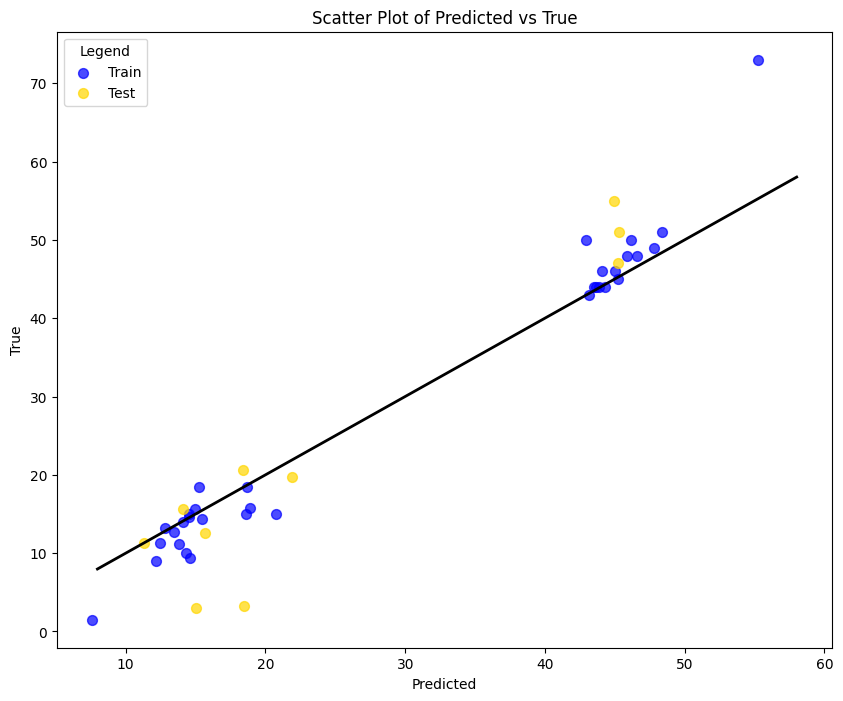

In [15]:
# path to data folder 
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

descriptor_list = ['ATS7dv', 'GATS1c', 'Xch-7d', 'PEOE_VSA3', 'VSA_EState2' ]

X_train = X_train[descriptor_list]
X_test = X_test[descriptor_list]

estimator = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# train the model
estimator.fit(X_train, y_train)
# predict the test set
y_pred = estimator.predict(X_test)
y_pred_train = estimator.predict(X_train)
# evaluate the model    
r2_test, mae_test = eval_model(estimator, y_test, y_pred)
r2_train, mae_train = eval_model(estimator, y_train, y_pred_train)
# show 3 digits after the decimal point
print(f"r2_test: {round(r2_test, 3)}, mae_test: {round(mae_test, 3)}")
print(f"r2_train: {round(r2_train, 3)}, mae_train: {round(mae_train, 3)}")
plot_scatter_plot(y_pred_train, y_pred, y_train, y_test, save_name='scatter_plot_saureus_distance.png')


In [12]:
# get cross validation score
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(estimator, X_train, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")

# get feature importance


/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/amirreza/micromamba/envs/nadetox/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column

Cross-validation scores: [-20.62670908  -0.22212905   0.75392183   0.55549387   0.46836335]
Mean cross-validation score: -3.814211816256351


In [13]:
# save the model
import pickle
import os 
if not os.path.exists('models'):
    os.makedirs('models')

with open('models/RF_reg_saureus_distance.pkl', 'wb') as f:
    pickle.dump(estimator, f)



